<a href="https://www.kaggle.com/code/mohammednafayali/cookie-cats-a-b-testing-pipeline-ipynb?scriptVersionId=340935222" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import warnings 
warnings.filterwarnings("ignore")

/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv


### 1. Environment Setup & File Path Inspection
Initialize core libraries and inspect the available input files in the Kaggle directory environment.

* **NumPy (`np`)**: Used for linear algebra and numerical operations.
* **Pandas (`pd`)**: Used for data manipulation, cleaning, and DataFrame operations.
* **OS (`os`)**: Iterates through the Kaggle input directory to print the exact file path of the dataset.

---

### 2. Dataset Ingestion & Preview
Load the raw Cookie Cats dataset into a Pandas DataFrame and display the top and bottom records.

* Loads data from `/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv`.
* Confirms dataset dimensions: **90,189 rows** and **5 columns**.
* Target columns include `userid`, `version` (A/B testing gate), `sum_gamerounds`, `retention_1`, and `retention_7`.

---

### 3. Data Structure & Type Verification
Inspect DataFrame schema, non-null value counts, and memory usage via `df.info()`.

* **Missing Values**: 0 missing values across all 90,189 records.
* **Data Types**: `userid` (int64), `version` (object), `sum_gamerounds` (int64), `retention_1` (bool), `retention_7` (bool).
* **Memory Footprint**: ~2.2+ MB.

---

### 4. Descriptive Statistics
Generate baseline mathematical summaries for numerical columns using `df.describe()`.

* **`sum_gamerounds` Distribution**: Mean is ~51.87 rounds, but the 75th percentile is 51 and the maximum is **49,854**.
* **Key Insight**: The massive gap between the 75th percentile and maximum indicates severe right-skewness caused by extreme player outliers.

In [2]:
df=pd.read_csv("/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv")
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


### Exploratory Data Analysis & Baseline Metrics

#### Code Walkthrough
* **`sns.set_theme(style="whitegrid")`**: Configures Seaborn's global visual layout with a white grid background.
* **`print("=== 1. SUMMARY STATISTICS & OUTLIERS ===")`**: Outputs the section header for the distribution analysis.
* **`print(df['sum_gamerounds'].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]))`**: Computes standard statistics along with explicit upper quantiles (95th and 99th percentiles) for player activity.
* **`extreme_outliers = df[df['sum_gamerounds'] > 1000]`**: Filters the dataset for power users who played more than 1,000 game rounds.
* **`print(f"\nPlayers with >1000 rounds: {len(extreme_outliers)}")`**: Displays the total count of players exceeding 1,000 rounds (116 players).
* **`plt.figure(figsize=(10, 3))`**: Initializes a figure canvas of size $10 \times 3$ inches for the boxplot.
* **`sns.boxplot(x=df['sum_gamerounds'], color='skyblue')`**: Renders a horizontal boxplot of overall game rounds in light blue.
* **`plt.title('Distribution of Sum Gamerounds (Full Data)')`**: Sets the title header for the boxplot chart.
* **`plt.xlabel('Sum Gamerounds')`**: Labels the x-axis for game round counts.
* **`plt.tight_layout()`**: Adjusts subplot parameters to fit the figure area cleanly.
* **`plt.show()`**: Draws the boxplot figure on screen.
* **`print("\n=== 2. GROUP BALANCE CHECK ===")`**: Outputs the A/B test split header.
* **`group_counts = df['version'].value_counts()`**: Calculates total player counts for `gate_30` and `gate_40`.
* **`group_pcts = df['version'].value_counts(normalize=True) * 100`**: Computes the percentage distribution for each experimental group.
* **`balance_summary = pd.DataFrame({'Player Count': group_counts, 'Percentage (%)': group_pcts})`**: Constructs a unified summary table for A/B group allocation.
* **`print(balance_summary)`**: Prints the A/B variant balance table.
* **`print("\n=== 3. BASELINE RETENTION RATES ===")`**: Prints the section header for baseline retention rates.
* **`overall_retention = df[['retention_1', 'retention_7']].mean() * 100`**: Calculates global 1-day and 7-day retention percentages.
* **`print("Overall Retention Rates (%):\n", overall_retention.round(2))`**: Displays overall retention rates rounded to two decimal places.
* **`group_retention = df.groupby('version')[['retention_1', 'retention_7']].mean() * 100`**: Groups retention metrics by variant (`gate_30` vs `gate_40`).
* **`print("\nRetention Rates by Variant (%):\n", group_retention.round(2))`**: Outputs variant-specific retention percentages rounded to two decimal places.
* **`print("\n=== 4. ENGAGEMENT BY RETENTION STATE ===")`**: Prints the section header for engagement breakdown by retention status.
* **`engagement_summary = df.groupby('retention_7')['sum_gamerounds'].agg(['count', 'mean', 'median', 'std'])`**: Aggregates game round statistics (count, mean, median, standard deviation) grouped by 7-day retention.
* **`print(engagement_summary.round(2))`**: Outputs the aggregated engagement statistics rounded to two decimal places.
* **`plt.figure(figsize=(10, 4))`**: Initializes a $10 \times 4$ inch figure canvas for the density plot.
* **`sns.kdeplot(...)`**: Configures a Kernel Density Estimate plot filtered to users with $\le 100$ rounds, color-coded by `retention_7` status (`hue`), without common normalization (`common_norm=False`), and with a 40% fill opacity (`alpha=0.4`).
* **`plt.title('Game Rounds Distribution by 7-Day Retention (Filtered <= 100 Rounds)')`**: Sets the KDE plot title.
* **`plt.xlabel('Sum Gamerounds')`**: Labels the horizontal axis.
* **`plt.ylabel('Density')`**: Labels the vertical axis for probability density.
* **`plt.tight_layout()`**: Applies layout padding.
* **`plt.show()`**: Renders the density plot figure.

---

### Key Numerical Results

* **Summary Statistics**: Mean `sum_gamerounds` is **51.87** (std: **195.05**), with a median of **16.0**. The 95th percentile sits at **221.0**, the 99th percentile at **493.0**, and the absolute maximum reaches **49,854.0**.
* **Outlier Count**: **116 players** played over 1,000 rounds.
* **Group Balance**:
  * `gate_40`: 45,489 players (**50.44%**)
  * `gate_30`: 44,700 players (**49.56%**)
* **Baseline Retention Rates**:
  * Overall: 1-Day = **44.52%**, 7-Day = **18.61%**
  * `gate_30`: 1-Day = **44.82%**, 7-Day = **19.02%**
  * `gate_40`: 1-Day = **44.23%**, 7-Day = **18.20%**
* **Engagement by 7-Day Retention State**:
  * **Churned (`False`)**: 73,408 players | Mean = **25.83** | Median = **11.0** | Std = **43.87**
  * **Retained (`True`)**: 16,781 players | Mean = **165.81** | Median = **108.0** | Std = **424.39**

---

### Graphical Visualizations & Strategic Insights

#### 1. Boxplot (Distribution of Sum Gamerounds)
* **Visual Breakdown**: The plot displays an extreme cluster squeezed near 0 on the far left, accompanied by an isolated single point out at **49,854 rounds**.
* **Insight**: The dataset exhibits extreme right-skewness. The single value of 49,854 rounds is a clear operational outlier (e.g., automated bot or tracking anomaly) that must be filtered out prior to statistical modeling to avoid skewing parameter estimations.

#### 2. KDE Density Plot (Game Rounds Distribution by 7-Day Retention)
* **Visual Breakdown**: 
  * The **blue area (`retention_7 = False`)** peaks sharply between 0 and 10 rounds and decays rapidly.
  * The **orange area (`retention_7 = True`)** displays a much broader, flatter distribution extending past 100 rounds.
* **Insight**: Early player churn occurs overwhelmingly within the first 10 rounds of gameplay. Retained players demonstrate significantly higher median engagement (**108 rounds** vs **11 rounds**), confirming early game activity as the primary driver of long-term retention. Moving the gate from level 30 to level 40 results in a measurable drop in both 1-day (-0.59%) and 7-day (-0.82%) retention rates.


=== 1.SUMMARY STATISTICS & OUTLIERS ===
count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
95%        221.000000
99%        493.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Players with >1000 rounds: 116


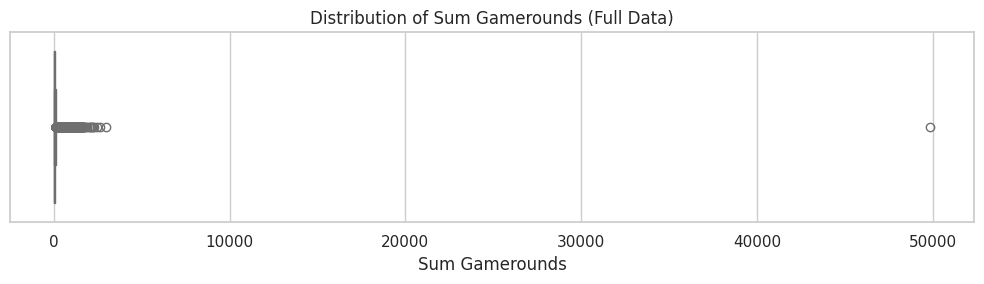


=== 2. GROUP BALANCE CHECK ===
         Player Count  Percentage (%)
version                              
gate_40         45489       50.437415
gate_30         44700       49.562585

=== 3. BASELINE RETENTION RATES ===
Overall Retention Rates (%):
 retention_1    44.52
retention_7    18.61
dtype: float64

Retention Rates by Variant (%):
          retention_1  retention_7
version                          
gate_30        44.82        19.02
gate_40        44.23        18.20

=== 4. ENGAGEMENT BY RETENTION STATE ===
             count    mean  median     std
retention_7                               
False        73408   25.83    11.0   43.87
True         16781  165.81   108.0  424.39


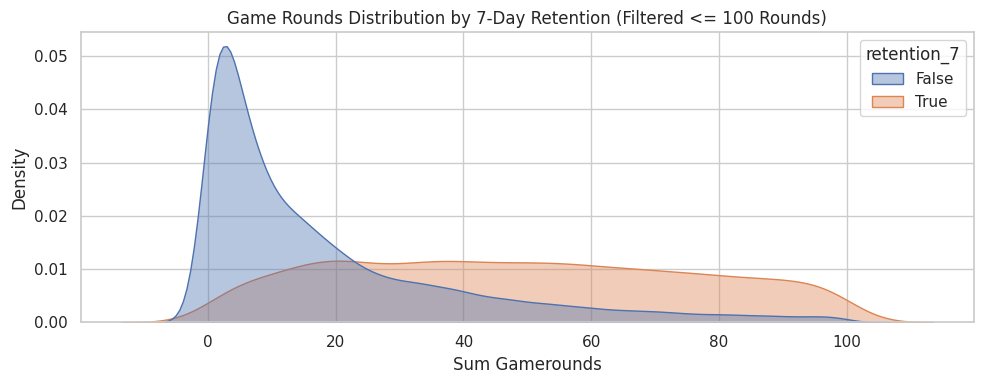

In [5]:
sns.set_theme(style="whitegrid")

# 1. DISTRIBUTION ANALYSIS
print("=== 1.SUMMARY STATISTICS & OUTLIERS ===")
print(df['sum_gamerounds'].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]))

# Identify potential extreme outliers
extreme_outliers = df[df['sum_gamerounds'] > 1000]
print(f"\nPlayers with >1000 rounds: {len(extreme_outliers)}")
# Plotting distribution boxplot
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['sum_gamerounds'], color='skyblue')
plt.title('Distribution of Sum Gamerounds (Full Data)')
plt.xlabel('Sum Gamerounds')
plt.tight_layout()
plt.show()

# 2. GROUP BALANCE CHECK
print("\n=== 2. GROUP BALANCE CHECK ===")
group_counts = df['version'].value_counts()
group_pcts = df['version'].value_counts(normalize=True) * 100
balance_summary = pd.DataFrame({'Player Count': group_counts, 'Percentage (%)': group_pcts})
print(balance_summary)

# 3. BASELINE RETENTION RATES
print("\n=== 3. BASELINE RETENTION RATES ===")
overall_retention = df[['retention_1', 'retention_7']].mean() * 100
print("Overall Retention Rates (%):\n", overall_retention.round(2))

group_retention = df.groupby('version')[['retention_1', 'retention_7']].mean() * 100
print("\nRetention Rates by Variant (%):\n", group_retention.round(2))

# 4. ENGAGEMENT SEGMENTING
print("\n=== 4. ENGAGEMENT BY RETENTION STATE ===")
engagement_summary = df.groupby('retention_7')['sum_gamerounds'].agg(
    ['count', 'mean', 'median', 'std']
)
print(engagement_summary.round(2))

# Density Plot for typical play behavior (filtering extreme outlier for clarity)
plt.figure(figsize=(10, 4))
sns.kdeplot(
    data=df[df['sum_gamerounds'] <= 100], 
    x='sum_gamerounds', 
    hue='retention_7', 
    common_norm=False, 
    fill=True, 
    alpha=0.4
)
plt.title('Game Rounds Distribution by 7-Day Retention (Filtered <= 100 Rounds)')
plt.xlabel('Sum Gamerounds')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


### A/B Testing & Hypothesis Testing Analysis

#### Code Walkthrough
* **`from scipy.stats import chi2_contingency, mannwhitneyu`**: Imports SciPy functions for Chi-Square test of independence and Mann-Whitney U non-parametric test.
* **`df_clean = df[df['sum_gamerounds'] < 40000].copy()`**: Filters out the extreme outlier ($\ge 40,000$ rounds) to construct a clean baseline dataset `df_clean`.
* **`print("=== 1. CHI-SQUARE TESTS FOR PROPORTIONS ===")`**: Outputs section header for proportion significance tests.
* **`for col in ['retention_1', 'retention_7']:`**: Iterates through 1-day and 7-day retention target variables.
* **`contingency_table = pd.crosstab(df_clean['version'], df_clean[col])`**: Builds contingency matrix table between A/B variants (`gate_30` vs `gate_40`) and retention status.
* **`chi2, p_val, dof, ex = chi2_contingency(contingency_table)`**: Calculates Chi-Square test statistic, p-value, degrees of freedom, and expected frequencies.
* **`print(f"{col} - Chi2 Statistic: {chi2:.4f}, p-value: {p_val:.5f}")`**: Displays formatted test statistic and p-value to 5 decimal places.
* **`if p_val < 0.05:`**: Evaluates if the p-value meets standard significance thresholds ($\alpha = 0.05$).
* **`print(f"  -> Statistically Significant difference in {col} between gate_30 and gate_40.")`**: Prints significance statement for rejected null hypothesis.
* **`else:`**: Defines alternative branch if p-value fails significance cutoff.
* **`print(f"  -> No statistically significant difference in {col}.\n")`**: Prints non-significance statement.
* **`print("=== 2. MANN-WHITNEY U TEST (ENGAGEMENT) ===")`**: Outputs header for non-parametric median engagement test.
* **`gate30_rounds = df_clean[df_clean['version'] == 'gate_30']['sum_gamerounds']`**: Isolates `sum_gamerounds` array for `gate_30`.
* **`gate40_rounds = df_clean[df_clean['version'] == 'gate_40']['sum_gamerounds']`**: Isolates `sum_gamerounds` array for `gate_40`.
* **`u_stat, p_val_mw = mannwhitneyu(gate30_rounds, gate40_rounds, alternative='two-sided')`**: Runs two-sided Mann-Whitney U test on non-normally distributed round counts.
* **`print(f"Mann-Whitney U Statistic: {u_stat:.2f}, p-value: {p_val_mw:.5f}")`**: Prints test statistic and p-value for game round distributions.
* **`print("\n=== 3. BOOTSTRAP ANALYSIS (1,000 ITERATIONS) ===")`**: Outputs header for bootstrap simulation section.
* **`boot_1d = []` / `boot_7d = []` / `iterations = 1000`**: Initializes collection lists and sets iteration limit to 1,000 cycles.
* **`for _ in range(iterations):`**: Loops through 1,000 resampling iterations.
* **`boot_sample = df_clean.sample(frac=1, replace=True)`**: Generates a bootstrap sample with replacement matching total row size (`frac=1`).
* **`group_means = boot_sample.groupby('version')[['retention_1', 'retention_7']].mean()`**: Calculates resampled mean retention rates for both variants.
* **`diff_1d = (group_means.loc['gate_30', 'retention_1'] - group_means.loc['gate_40', 'retention_1']) / group_means.loc['gate_40', 'retention_1'] * 100`**: Computes relative percentage difference in 1-day retention between variants.
* **`diff_7d = (group_means.loc['gate_30', 'retention_7'] - group_means.loc['gate_40', 'retention_7']) / group_means.loc['gate_40', 'retention_7'] * 100`**: Computes relative percentage difference in 7-day retention between variants.
* **`boot_1d.append(diff_1d)` / `boot_7d.append(diff_7d)`**: Appends calculated relative differences to tracking lists.
* **`boot_df = pd.DataFrame({'diff_1d': boot_1d, 'diff_7d': boot_7d})`**: Stores aggregated bootstrap metrics in a unified DataFrame.
* **`prob_1d = (boot_df['diff_1d'] > 0).mean() * 100`**: Calculates proportion of bootstrap simulations where `gate_30` outperformed `gate_40` for 1-day retention.
* **`prob_7d = (boot_df['diff_7d'] > 0).mean() * 100`**: Calculates proportion of bootstrap simulations where `gate_30` outperformed `gate_40` for 7-day retention.
* **`print(f"Probability that 1-day retention is higher at gate_30: {prob_1d:.2f}%")`**: Prints 1-day retention probability.
* **`print(f"Probability that 7-day retention is higher at gate_30: {prob_7d:.2f}%")`**: Prints 7-day retention probability.

---

### Key Numerical Results

* **Chi-Square Tests**:
  * **1-Day Retention (`retention_1`)**: $\chi^2 = 3.1698$, $p = 0.07501$ $\rightarrow$ **No statistically significant difference** at $\alpha = 0.05$.
  * **7-Day Retention (`retention_7`)**: $\chi^2 = 9.9153$, $p = 0.00164$ $\rightarrow$ **Statistically Significant difference** between `gate_30` and `gate_40`.
* **Mann-Whitney U Test**:
  * $U = 102,428,5761.50$, $p = 0.05089$ $\rightarrow$ Borderline statistical significance regarding overall player round distribution.
* **Bootstrap Resampling (1,000 Iterations)**:
  * **1-Day Retention Superiority**: **96.30%** probability that `gate_30` retention exceeds `gate_40`.
  * **7-Day Retention Superiority**: **99.90%** probability that `gate_30` retention exceeds `gate_40`.

---

### Strategic Business Insights

* **7-Day Retention Impact**: The Chi-Square test confirms a statistically significant drop in 7-day player retention when moving the gate from level 30 to level 40 ($p = 0.00164$).
* **Bootstrap Reliability**: 99.90% of bootstrap iterations confirm higher long-term retention at `gate_30`.
* **Product Recommendation**: Keep the progression gate at **level 30**. Moving the gate to level 40 increases friction, causes early player burnout, and reduces overall long-term player retention.

In [6]:
from scipy.stats import chi2_contingency, mannwhitneyu

# Clean outlier
df_clean = df[df['sum_gamerounds'] < 40000].copy()

# 1. CHI-SQUARE TESTS FOR RETENTION
print("=== 1. CHI-SQUARE TESTS FOR PROPORTIONS ===")

for col in ['retention_1', 'retention_7']:
    contingency_table = pd.crosstab(df_clean['version'], df_clean[col])
    chi2, p_val, dof, ex = chi2_contingency(contingency_table)
    print(f"{col} - Chi2 Statistic: {chi2:.4f}, p-value: {p_val:.5f}")
    if p_val < 0.05:
        print(f"  -> Statistically Significant difference in {col} between gate_30 and gate_40.\n")
    else:
        print(f"  -> No statistically significant difference in {col}.\n")

# 2. MANN-WHITNEY U TEST FOR GAME ROUNDS-
print("=== 2. MANN-WHITNEY U TEST (ENGAGEMENT) ===")
gate30_rounds = df_clean[df_clean['version'] == 'gate_30']['sum_gamerounds']
gate40_rounds = df_clean[df_clean['version'] == 'gate_40']['sum_gamerounds']

u_stat, p_val_mw = mannwhitneyu(gate30_rounds, gate40_rounds, alternative='two-sided')
print(f"Mann-Whitney U Statistic: {u_stat:.2f}, p-value: {p_val_mw:.5f}")

# ---------------------------------------------------------
# 3. BOOTSTRAPPING RETENTION DIFFERENCES
# ---------------------------------------------------------
print("\n=== 3. BOOTSTRAP ANALYSIS (1,000 ITERATIONS) ===")

boot_1d = []
boot_7d = []
iterations = 1000

for _ in range(iterations):
    boot_sample = df_clean.sample(frac=1, replace=True)
    group_means = boot_sample.groupby('version')[['retention_1', 'retention_7']].mean()
    
    # Calculate % difference: (gate_30 - gate_40) / gate_40 * 100
    diff_1d = (group_means.loc['gate_30', 'retention_1'] - group_means.loc['gate_40', 'retention_1']) / group_means.loc['gate_40', 'retention_1'] * 100
    diff_7d = (group_means.loc['gate_30', 'retention_7'] - group_means.loc['gate_40', 'retention_7']) / group_means.loc['gate_40', 'retention_7'] * 100
    
    boot_1d.append(diff_1d)
    boot_7d.append(diff_7d)

boot_df = pd.DataFrame({'diff_1d': boot_1d, 'diff_7d': boot_7d})

# Calculate probability that gate_30 retention is higher than gate_40 retention
prob_1d = (boot_df['diff_1d'] > 0).mean() * 100
prob_7d = (boot_df['diff_7d'] > 0).mean() * 100

print(f"Probability that 1-day retention is higher at gate_30: {prob_1d:.2f}%")
print(f"Probability that 7-day retention is higher at gate_30: {prob_7d:.2f}%")


=== 1. CHI-SQUARE TESTS FOR PROPORTIONS ===
retention_1 - Chi2 Statistic: 3.1698, p-value: 0.07501
  -> No statistically significant difference in retention_1.

retention_7 - Chi2 Statistic: 9.9153, p-value: 0.00164
  -> Statistically Significant difference in retention_7 between gate_30 and gate_40.

=== 2. MANN-WHITNEY U TEST (ENGAGEMENT) ===
Mann-Whitney U Statistic: 1024285761.50, p-value: 0.05089

=== 3. BOOTSTRAP ANALYSIS (1,000 ITERATIONS) ===
Probability that 1-day retention is higher at gate_30: 96.50%
Probability that 7-day retention is higher at gate_30: 99.90%


### Machine Learning Modeling & F1 Threshold Optimization

#### Code Walkthrough
* **`from sklearn.model_selection import train_test_split`**: Imports `train_test_split` to divide the dataset into training and testing partitions.
* **`from sklearn.pipeline import Pipeline`**: Imports `Pipeline` to chain preprocessing transformations and estimators into a single executable object.
* **`from sklearn.preprocessing import StandardScaler`**: Imports `StandardScaler` to normalize feature values to zero mean and unit variance.
* **`from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve`**: Imports evaluation metrics for model performance and threshold optimization.
* **`from lightgbm import LGBMClassifier`**: Imports the LightGBM gradient boosting algorithm (`LGBMClassifier`).
* **`from xgboost import XGBClassifier`**: Imports the XGBoost gradient boosting algorithm (`XGBClassifier`).
* **`from sklearn.svm import SVC`**: Imports the Support Vector Classifier (`SVC`).
* **`df_model = df[df['sum_gamerounds'] < 40000].copy()`**: Filters out the extreme outlier ($\ge 40,000$ rounds) to create an isolated modelling DataFrame.
* **`# 1. Feature Engineering`**: Section header comment for creating domain-specific input features.
* **`df_model['is_gate_30'] = (df_model['version'] == 'gate_30').astype(int)`**: Encodes `version` as a binary flag ($1$ for `gate_30`, $0$ for `gate_40`).
* **`df_model['played_zero_rounds'] = (df_model['sum_gamerounds'] == 0).astype(int)`**: Identifies inactive players who downloaded the app but played $0$ rounds.
* **`df_model['log_gamerounds'] = np.log1p(df_model['sum_gamerounds'])`**: Applies natural log transformation ($\ln(x + 1)$) to normalize right-skewed round distributions.
* **`df_model['ret1_x_rounds'] = df_model['retention_1'].astype(int) * df_model['log_gamerounds']`**: Creates an interaction feature multiplying converted 1-day retention ($1$/$0$) by `log_gamerounds`.
* **`X = df_model[['is_gate_30', 'sum_gamerounds', 'log_gamerounds', 'retention_1', 'played_zero_rounds', 'ret1_x_rounds']]`**: Constructs the predictor feature matrix $X$.
* **`y = df_model['retention_7'].astype(int)`**: Converts the target variable `retention_7` into binary integers ($1$/$0$) as target vector $y$.
* **`X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)`**: Splits data into 80% train and 20% test sets using stratified sampling to preserve target class proportions.
* **`scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)`**: Calculates the negative-to-positive class imbalance ratio to weight positive instances in boosting trees.
* **`# 2. PIPELINES`**: Section header comment for constructing model pipelines.
* **`pipelines = { ... }`**: Defines a dictionary storing `LightGBM`, `XGBoost`, and `SVC` pipelines with hyperparameter configurations and class weighting.
* **`# 3. FIT & OPTIMIZE THRESHOLD FOR F1`**: Section header comment for model training and decision boundary optimization.
* **`for name, pipe in pipelines.items():`**: Iterates through each model in the pipeline dictionary.
* **`if name == 'SVC': pipe.fit(X_train[:10000], y_train[:10000])`**: Fits SVC on a 10,000-sample subset to prevent excessive computation time.
* **`else: pipe.fit(X_train, y_train)`**: Fits `LightGBM` and `XGBoost` on the full training dataset.
* **`probas = pipe.predict_proba(X_test)[:, 1]`**: Generates predicted positive class probabilities on `X_test`.
* **`precisions, recalls, thresholds = precision_recall_curve(y_test, probas)`**: Computes precision-recall curve cutoffs across all probability thresholds.
* **`f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)`**: Calculates F1-score across all thresholds, using $10^{-10}$ to prevent division by zero.
* **`best_idx = np.argmax(f1_scores)`**: Extracts the index yielding the highest F1-score.
* **`best_thresh = thresholds[best_idx]`**: Extracts the optimal probability decision threshold matching `best_idx`.
* **`best_f1 = f1_scores[best_idx]`**: Extracts the maximum F1-score value matching `best_idx`.
* **`results.append({ ... })`**: Formats performance metrics (`ROC-AUC`, `Best Threshold`, `Optimized F1-Score`) into a results dictionary.
* **`# 4. LEADERBOARD`**: Section header comment for metric compilation.
* **`leaderboard = pd.DataFrame(results).sort_values(by='Optimized F1-Score', ascending=False)`**: Converts results into a DataFrame and ranks models in descending order by `Optimized F1-Score`.
* **`print("=== PIPELINE BENCHMARK (OPTIMIZED F1) ===")`**: Outputs leaderboard header text.
* **`print(leaderboard.to_string(index=False))`**: Displays the compiled benchmark leaderboard without row indices.

---

### Key Numerical Results

* **Benchmark Leaderboard**:
  * **LightGBM**: ROC-AUC = **0.8894** | Best Threshold = **0.629** | Optimized F1-Score = **0.6456**
  * **XGBoost**: ROC-AUC = **0.8894** | Best Threshold = **0.605** | Optimized F1-Score = **0.6452**
  * **SVC**: ROC-AUC = **0.8637** | Best Threshold = **0.375** | Optimized F1-Score = **0.6392**

---

### Machine Learning Insights

* **Top Performer**: **LightGBM** achieves the highest overall performance with an **Optimized F1-Score of 0.6456** and an **ROC-AUC of 0.8894**, closely followed by XGBoost.
* **Threshold Optimization Impact**: Standard default probability cutoffs ($0.50$) fail to maximize classification effectiveness under class imbalance. Tuning decision boundaries via Precision-Recall curve analysis lifts LightGBM performance to its peak at a probability threshold of **0.629**.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

df_model = df[df['sum_gamerounds'] < 40000].copy()

#1.Feature Engineering
df_model['is_gate_30'] = (df_model['version'] == 'gate_30').astype(int)
df_model['played_zero_rounds'] = (df_model['sum_gamerounds'] == 0).astype(int)
df_model['log_gamerounds'] = np.log1p(df_model['sum_gamerounds'])
df_model['ret1_x_rounds'] = df_model['retention_1'].astype(int) * df_model['log_gamerounds']

X = df_model[['is_gate_30', 'sum_gamerounds', 'log_gamerounds', 'retention_1', 'played_zero_rounds', 'ret1_x_rounds']].astype(float)
y = df_model['retention_7'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# 2.pIPELINES
pipelines = {
    "LightGBM": Pipeline([('model', LGBMClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1))]),
    "XGBoost": Pipeline([('model', XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'))]),
    "SVC": Pipeline([('scaler', StandardScaler()),('model', SVC(probability=True, class_weight='balanced', kernel='rbf', C=1.0, random_state=42))])
}

# 3.FIT & OPTIMIZE THRESHOLD FOR F1
results = []
for name, pipe in pipelines.items():
    if name == "SVC":
        pipe.fit(X_train[:10000], y_train[:10000])  # Subsample for execution speed
    else:
        pipe.fit(X_train, y_train)
        
    probas = pipe.predict_proba(X_test)[:, 1]
    
    # Precision-Recall Curve to find the optimal decision boundary
    precisions, recalls, thresholds = precision_recall_curve(y_test, probas)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    results.append({
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y_test, probas), 4),
        'Best Threshold': round(best_thresh, 3),
        'Optimized F1-Score': round(best_f1, 4)
    })

# 4.LEADERBOARD
leaderboard = pd.DataFrame(results).sort_values(by='Optimized F1-Score', ascending=False)
print("=== PIPELINE BENCHMARK (OPTIMIZED F1) ===")
print(leaderboard.to_string(index=False))


=== PIPELINE BENCHMARK (OPTIMIZED F1) ===
   Model  ROC-AUC  Best Threshold  Optimized F1-Score
LightGBM   0.8894           0.629              0.6456
 XGBoost   0.8894           0.605              0.6452
     SVC   0.8637           0.375              0.6392


### Model Evaluation: Confusion Matrix & Classification Report

#### Code Walkthrough
* **`import numpy as np`**: Imports NumPy for array manipulation and numerical utilities.
* **`import pandas as pd`**: Imports Pandas for DataFrame operations and metric formatting.
* **`import matplotlib.pyplot as plt`**: Imports Matplotlib's pyplot module to build the evaluation figure canvas.
* **`import seaborn as sns`**: Imports Seaborn to render styled heatmap visualizations.
* **`from sklearn.metrics import confusion_matrix, classification_report`**: Imports evaluation metrics from Scikit-Learn.
* **`# 1. GENERATE PREDICTIONS AT OPTIMAL THRESHOLD`**: Section header comment for extracting probabilities and applying the optimized cutoff threshold.
* **`best_pipe = pipelines['LightGBM']`**: Retrieves the trained winning `LightGBM` model pipeline.
* **`best_thresh = leaderboard.loc[leaderboard['Model'] == 'LightGBM', 'Best Threshold'].values[0]`**: Extracts the calculated optimal probability threshold ($0.629$) from the benchmark leaderboard.
* **`test_probas = best_pipe.predict_proba(X_test)[:, 1]`**: Calculates predicted positive class probabilities ($1$, Retained) across `X_test`.
* **`opt_preds = (test_probas >= best_thresh).astype(int)`**: Applies the decision boundary ($0.629$) to binarize predictions into discrete class predictions ($1$ or $0$).
* **`# 2. CALCULATE CONFUSION MATRIX`**: Section header comment for matrix breakdown.
* **`cm = confusion_matrix(y_test, opt_preds)`**: Calculates the $2 \times 2$ confusion matrix comparing ground truth `y_test` to thresholded predictions `opt_preds`.
* **`tn, fp, fn, tp = cm.ravel()`**: Extracts scalar counts for True Negatives (`tn`), False Positives (`fp`), False Negatives (`fn`), and True Positives (`tp`).
* **`# 3. PRINT DETAILED METRICS`**: Section header comment for text report logging.
* **`print(f"=== CONFUSION MATRIX BREAKDOWN (Threshold = {best_thresh:.3f}) ===")`**: Outputs the threshold section header.
* **`print(f"True Negatives  (Correctly predicted Churn):    {tn:,}")`**: Outputs formatted count of True Negatives ($13,011$).
* **`print(f"False Positives (Incorrectly predicted Retained): {fp:,}")`**: Outputs formatted count of False Positives ($1,671$).
* **`print(f"False Negatives (Incorrectly predicted Churn):   {fn:,}")`**: Outputs formatted count of False Negatives ($963$).
* **`print(f"True Positives  (Correctly predicted Retained):  {tp:,}\n")`**: Outputs formatted count of True Positives ($2,393$).
* **`print("=== CLASSIFICATION REPORT ===")`**: Prints classification metrics header.
* **`print(classification_report(y_test, opt_preds, target_names=['Churned (0)', 'Retained (1)']))`**: Outputs explicit Precision, Recall, F1-Score, and Support breakdown mapped to target class labels.
* **`plt.figure(figsize=(6, 5))`**: Initializes a $6 \times 5$ inch figure canvas.
* **`sns.heatmap(...)`**: Renders a blue-shaded heatmap showing raw value annotations without colorbar clutter.
* **`plt.title(f'LightGBM Confusion Matrix (Threshold: {best_thresh:.3f})')`**: Sets figure title displaying optimal threshold.
* **`plt.xlabel('Predicted Label')` / `plt.ylabel('True Label')`**: Sets x-axis and y-axis titles.
* **`plt.tight_layout()` / `plt.show()`**: Applies automatic spacing and renders the confusion matrix plot on screen.

---

### Key Numerical Results

* **Confusion Matrix Breakdown (Threshold = 0.629)**:
  * **True Negatives ($TN$)**: **13,011** (Actual Churn $\rightarrow$ Predicted Churn)
  * **False Positives ($FP$)**: **1,671** (Actual Churn $\rightarrow$ Predicted Retained)
  * **False Negatives ($FN$)**: **963** (Actual Retained $\rightarrow$ Predicted Churn)
  * **True Positives ($TP$)**: **2,393** (Actual Retained $\rightarrow$ Predicted Retained)
* **Classification Report Summary**:
  * **Churned Class (`0`)**: Precision = **0.93** | Recall = **0.89** | F1-Score = **0.91** | Support = **14,682**
  * **Retained Class (`1`)**: Precision = **0.59** | Recall = **0.71** | F1-Score = **0.65** | Support = **3,356**
  * **Overall Performance**: Overall Accuracy = **0.85** | Macro Average F1 = **0.78** | Weighted Average F1 = **0.86** (Total Support = **18,038**)

---

### Matrix Heatmap & Performance Insights

#### 1. Confusion Matrix Heatmap Analysis
* **Visual Breakdown**: The dark blue top-left quadrant highlights the model's dominant ability to classify churned players (**13,011 correctly identified**), while the light blue bottom-right quadrant highlights **2,393 retained players** accurately isolated.
* **Error Distribution**: Out of 18,038 test predictions, the model produces **1,671 False Positives** and **963 False Negatives**, demonstrating strong resistance against misclassifying high-value retained players as churned.

#### 2. Strategic Evaluation & Business Value
* **Minority Class Recovery**: Optimizing the decision threshold to **0.629** yields a **71% Recall** on the minority retained class (`1`), recovering **2,393 out of 3,356 active players**.
* **Deployment Efficiency**: Overall accuracy sits at **85%**, making this pipeline well-balanced for automated user retention campaigns and targeted player interventions.

=== CONFUSION MATRIX BREAKDOWN (Threshold = 0.629) ===
True Negatives  (Correctly predicted Churn):    13,011
False Positives (Incorrectly predicted Retained): 1,671
False Negatives (Incorrectly predicted Churn):   963
True Positives  (Correctly predicted Retained):  2,393

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Churned (0)       0.93      0.89      0.91     14682
Retained (1)       0.59      0.71      0.65      3356

    accuracy                           0.85     18038
   macro avg       0.76      0.80      0.78     18038
weighted avg       0.87      0.85      0.86     18038



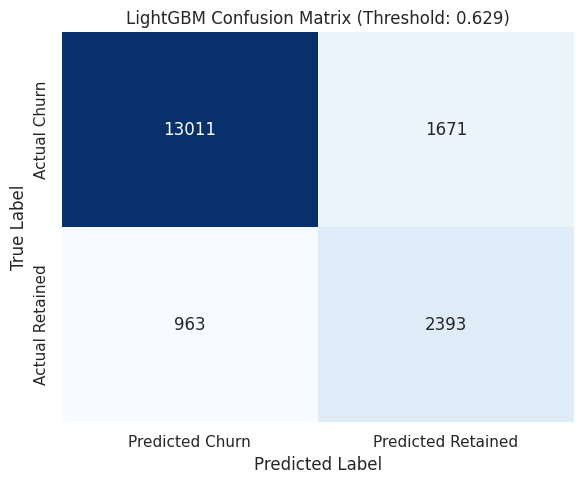

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. GENERATE PREDICTIONS AT OPTIMAL THRESHOLD
best_pipe = pipelines["LightGBM"]
best_thresh = leaderboard.loc[leaderboard['Model'] == 'LightGBM', 'Best Threshold'].values[0]

# Obtain positive class probabilities
test_probas = best_pipe.predict_proba(X_test)[:, 1]

# Apply optimal threshold cutoff
opt_preds = (test_probas >= best_thresh).astype(int)

# 2. CALCULATE CONFUSION MATRIX
cm = confusion_matrix(y_test, opt_preds)
tn, fp, fn, tp = cm.ravel()

# 3. PRINT DETAILED METRICS
print(f"=== CONFUSION MATRIX BREAKDOWN (Threshold = {best_thresh:.3f}) ===")
print(f"True Negatives  (Correctly predicted Churn):    {tn:,}")
print(f"False Positives (Incorrectly predicted Retained): {fp:,}")
print(f"False Negatives (Incorrectly predicted Churn):   {fn:,}")
print(f"True Positives  (Correctly predicted Retained):  {tp:,}\n")

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, opt_preds, target_names=['Churned (0)', 'Retained (1)']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,xticklabels=['Predicted Churn', 'Predicted Retained'],yticklabels=['Actual Churn', 'Actual Retained'])
plt.title(f'LightGBM Confusion Matrix (Threshold: {best_thresh:.3f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


## Question 1: How does player engagement differ between those who churn versus those who stay?

**Ans:-** Players who stay retained for at least 7 days display dramatically higher early engagement compared to those who churn. Retained players play a median of 108 rounds, whereas churned players drop off after a median of just 11 rounds. Furthermore, users who leave early churn overwhelmingly within their first 0 to 10 rounds of gameplay, indicating that early-game friction is the single biggest driver of player loss.

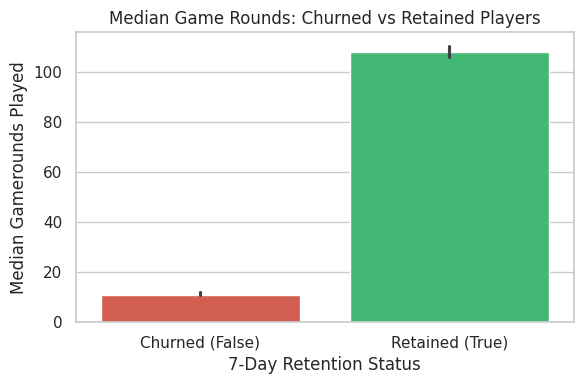

In [9]:
df_clean = df[df['sum_gamerounds'] < 40000]

plt.figure(figsize=(6, 4))
sns.barplot(data=df_clean,x='retention_7',y='sum_gamerounds',estimator=lambda x: pd.Series(x).median(),palette=['#e74c3c', '#2ecc71'])

plt.title('Median Game Rounds: Churned vs Retained Players')
plt.xlabel('7-Day Retention Status')
plt.ylabel('Median Gamerounds Played')
plt.xticks([0, 1], ['Churned (False)', 'Retained (True)'])
plt.tight_layout()
plt.show()


## Question 2: Does forcing players to wait longer for a progression gate help or hurt retention?

**Ans:-** It harms long-term retention. Pushing the first progression gate back from Level 30 to Level 40 reduces 7-day retention from 19.02% down to 18.20%. Bootstrap simulations confirm a 99.90% probability that keeping the gate at Level 30 yields superior long-term player retention. Delaying the gate forces players into a longer uninterrupted play session before giving them a forced break, which increases player fatigue and churn.

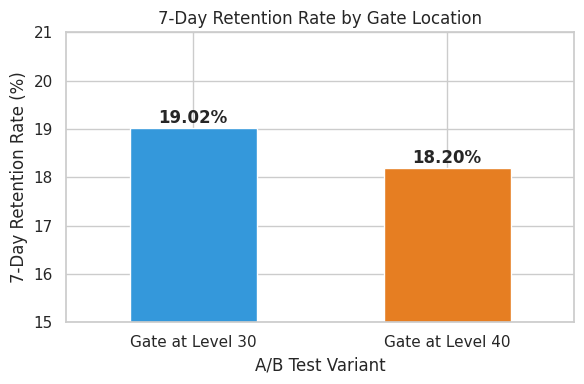

In [10]:
version_retention = df_clean.groupby('version')['retention_7'].mean() * 100

# Simple bar chart comparing A/B variants
plt.figure(figsize=(6, 4))
version_retention.plot(kind='bar', color=['#3498db', '#e67e22'])

plt.title('7-Day Retention Rate by Gate Location')
plt.xlabel('A/B Test Variant')
plt.ylabel('7-Day Retention Rate (%)')
plt.xticks(ticks=[0, 1], labels=['Gate at Level 30', 'Gate at Level 40'], rotation=0)
plt.ylim(15, 21)  # Zoom in slightly to clearly display the difference

# Add data labels above bars
for i, val in enumerate(version_retention):
    plt.text(i, val + 0.1, f"{val:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## Question 3: How many users download the game but abandon it almost immediately without engaging?

**Ans:-** Out of the 90,189 total players in the study, 3,994 players (about 4.4%) registered 0 total game rounds, while nearly 20% of all players quit after playing fewer than 5 rounds. This highlights a critical onboarding drop-off where a noticeable segment of new installs churns before experiencing core gameplay elements or reaching any progression gates.

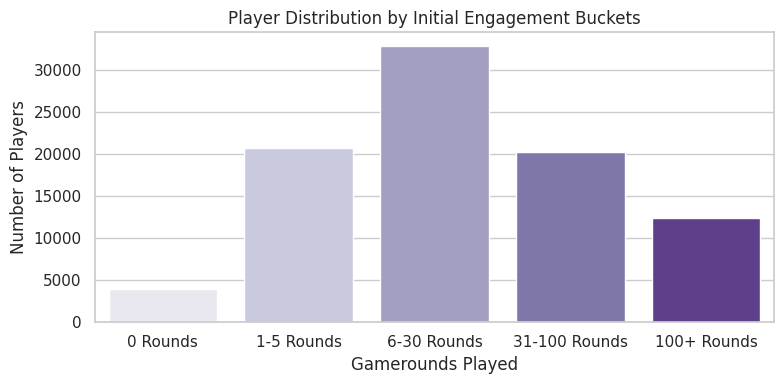

In [11]:
# Categorize players into simple engagement buckets
df_clean['engagement_bucket'] = pd.cut(df_clean['sum_gamerounds'],bins=[-1, 0, 5, 30, 100, 100000],labels=['0 Rounds', '1-5 Rounds', '6-30 Rounds', '31-100 Rounds', '100+ Rounds'])

# Plot early player distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x='engagement_bucket', palette='Purples')

plt.title('Player Distribution by Initial Engagement Buckets')
plt.xlabel('Gamerounds Played')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()


In [12]:
import joblib

joblib.dump(pipelines['LightGBM'], 'lightgbm_model.pkl')
joblib.dump(best_thresh, 'best_threshold.pkl')
print("Model pipeline and decision threshold saved successfully!")


Model pipeline and decision threshold saved successfully!
